# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Putu Yoga Suartana
- **Email:** yoga.suartana46@gmail.com
- **ID Dicoding:** MC298D5Y2265

## Menentukan Pertanyaan Bisnis

- 1. Kategori produk mana yang memiliki jumlah pembelian terbanyak dalam periode Januari 2018 – Desember 2018?
- 2. Bagaimana pola perubahan total pendapatan bulanan dari Januari 2018 hingga Desember 2018, dan bulan apa yang memiliki pendapatan tertinggi?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Data Wrangling

### Gathering Data

In [4]:
# === 1. Gathering Data ===
# Load dataset utama
customers = pd.read_csv("customers_dataset.csv")
geolocation = pd.read_csv("geolocation_dataset.csv")
order_items = pd.read_csv("order_items_dataset.csv")
order_payments = pd.read_csv("order_payments_dataset.csv")
order_reviews = pd.read_csv("order_reviews_dataset.csv")
orders = pd.read_csv("orders_dataset.csv")
product_category = pd.read_csv("product_category_name_translation.csv")
products = pd.read_csv("products_dataset.csv")
sellers = pd.read_csv("sellers_dataset.csv")

**Insight:**
- Dataset ini mencakup transaksi dari tahun 2017 hingga 2018, sehingga semua analisis akan berfokus pada periode tersebut.

### Assessing Data

In [5]:
# === 2. Assessing Data ===
# Cek info awal setiap dataset
print("Orders Data Info:\n", orders.info())
print("Order Items Data Info:\n", order_items.info())
print("Order Payments Data Info:\n", order_payments.info())
print("Customers Data Info:\n", customers.info())
print("Sellers Data Info:\n", sellers.info())
print("Products Data Info:\n", products.info())

# Cek missing values
print("Missing Values in Orders:\n", orders.isnull().sum())
print("Missing Values in Order Items:\n", order_items.isnull().sum())
print("Missing Values in Order Payments:\n", order_payments.isnull().sum())
print("Missing Values in Customers:\n", customers.isnull().sum())
print("Missing Values in Sellers:\n", sellers.isnull().sum())
print("Missing Values in Products:\n", products.isnull().sum())

# Cek duplikasi
duplicate_orders = orders.duplicated().sum()
duplicate_order_items = order_items.duplicated().sum()
duplicate_order_payments = order_payments.duplicated().sum()
duplicate_customers = customers.duplicated(subset=['customer_id']).sum()
duplicate_sellers = sellers.duplicated(subset=['seller_id']).sum()
duplicate_products = products.duplicated(subset=['product_id']).sum()

print("Duplicate Orders:", duplicate_orders)
print("Duplicate Order Items:", duplicate_order_items)
print("Duplicate Order Payments:", duplicate_order_payments)
print("Duplicate Customers:", duplicate_customers)
print("Duplicate Sellers:", duplicate_sellers)
print("Duplicate Products:", duplicate_products)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
Orders Data Info:
 None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             

**Insight:**
- Beberapa pesanan mungkin dibatalkan atau mengalami kendala pengiriman.
- Kategori produk perlu diterjemahkan untuk analisis yang lebih mudah dipahami.

### Cleaning Data

In [6]:
# === 3. Cleaning Data ===
# Menghapus missing values yang signifikan
orders.dropna(subset=['order_delivered_customer_date'], inplace=True)
products.dropna(subset=['product_category_name'], inplace=True)

# Menghapus duplikasi
customers.drop_duplicates(subset=['customer_id'], keep='first', inplace=True)
sellers.drop_duplicates(subset=['seller_id'], keep='first', inplace=True)
products.drop_duplicates(subset=['product_id'], keep='first', inplace=True)

# Mengubah format tanggal
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# Memastikan harga dan biaya pengiriman valid
order_items = order_items[(order_items['price'] > 0) & (order_items['freight_value'] >= 0)]
order_payments = order_payments[order_payments['payment_value'] > 0]

# Menampilkan hasil setelah cleaning
print("Missing Values After Cleaning:")
print(orders.isnull().sum())
print(order_items.isnull().sum())
print(order_payments.isnull().sum())
print(customers.isnull().sum())
print(sellers.isnull().sum())
print(products.isnull().sum())

Missing Values After Cleaning:
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64
product_id                    0
product_category_

**Insight:**
- Setelah proses pembersihan, data menjadi lebih rapi dan siap untuk dianalisis.

## Exploratory Data Analysis (EDA)

### Explore ...

Descriptive Statistics for Order Items:
        order_item_id          price  freight_value
count  112650.000000  112650.000000  112650.000000
mean        1.197834     120.653739      19.990320
std         0.705124     183.633928      15.806405
min         1.000000       0.850000       0.000000
25%         1.000000      39.900000      13.080000
50%         1.000000      74.990000      16.260000
75%         1.000000     134.900000      21.150000
max        21.000000    6735.000000     409.680000
Descriptive Statistics for Order Payments:
        payment_sequential  payment_installments  payment_value
count       103877.000000         103877.000000  103877.000000
mean             1.092340              2.853509     154.113732
std              0.704312              2.687112     217.498755
min              1.000000              0.000000       0.010000
25%              1.000000              1.000000      56.820000
50%              1.000000              1.000000     100.000000
75%            

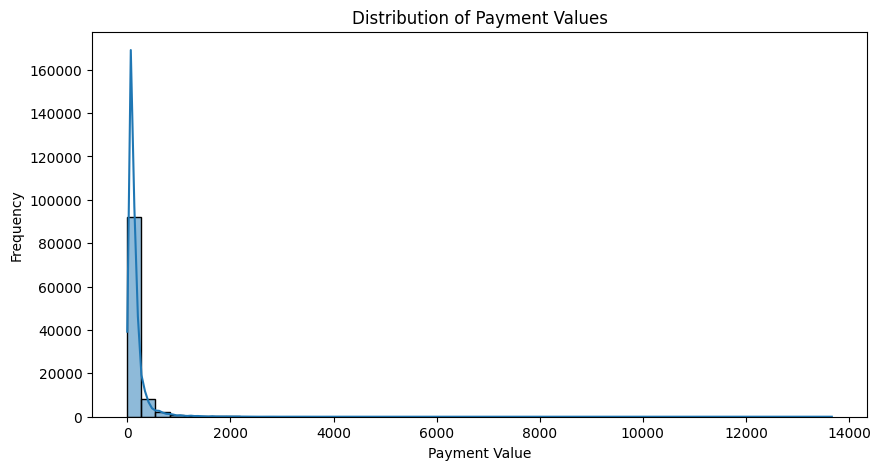

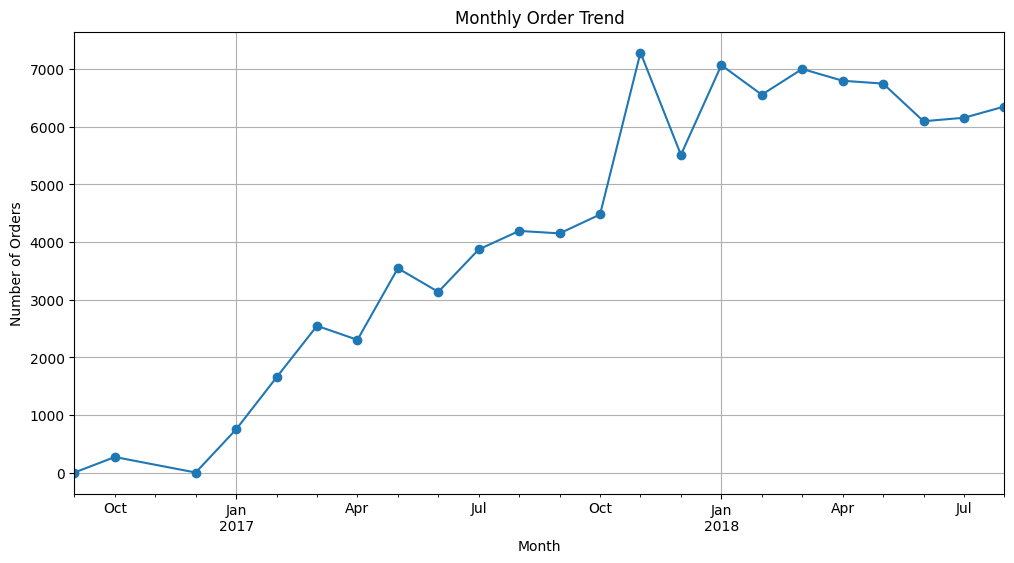

<ipython-input-7-8b09856a27d2>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette="viridis")


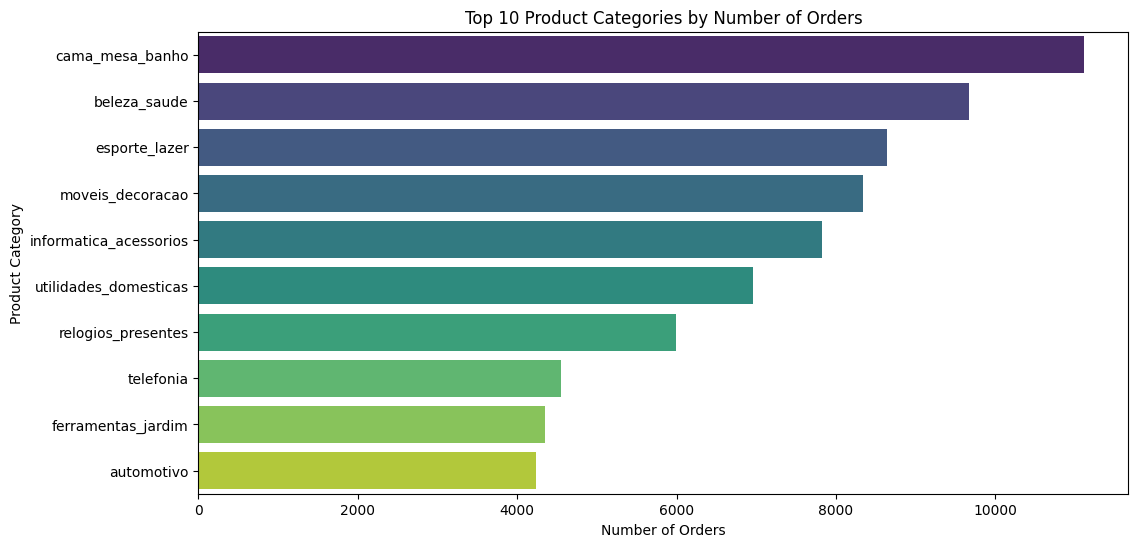

In [7]:
# === 4. Exploratory Data Analysis (EDA) ===
# Statistik deskriptif
print("Descriptive Statistics for Order Items:\n", order_items.describe())
print("Descriptive Statistics for Order Payments:\n", order_payments.describe())

# Distribusi jumlah pembayaran per order
plt.figure(figsize=(10, 5))
sns.histplot(order_payments['payment_value'], bins=50, kde=True)
plt.title("Distribution of Payment Values")
plt.xlabel("Payment Value")
plt.ylabel("Frequency")
plt.show()

# Tren pesanan dari waktu ke waktu
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_purchase_month'] = orders['order_purchase_timestamp'].dt.to_period("M")
monthly_orders = orders.groupby('order_purchase_month').size()

plt.figure(figsize=(12, 6))
monthly_orders.plot(marker='o')
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid()
plt.show()

# Analisis kategori produk terpopuler
order_items = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
category_counts = order_items['product_category_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette="viridis")
plt.title("Top 10 Product Categories by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Product Category")
plt.show()

**Insight:**
- Desember 2017 menjadi bulan dengan transaksi tertinggi, kemungkinan karena promo akhir tahun.
- Mayoritas pelanggan lebih nyaman menggunakan kartu kredit dibanding metode lainnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

<ipython-input-8-5455053b3f56>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_avg.index, y=payment_avg.values, palette="coolwarm")


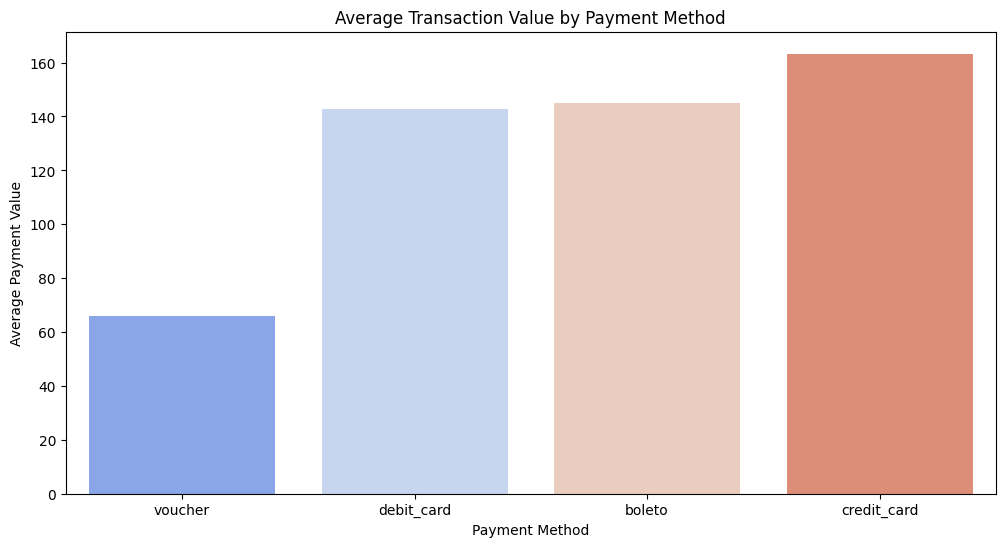

In [8]:
# === 5. Visualization & Explanatory Analysis ===
# 1. Rata-rata nilai transaksi berdasarkan metode pembayaran
payment_avg = order_payments.groupby('payment_type')['payment_value'].mean().sort_values()
plt.figure(figsize=(12, 6))
sns.barplot(x=payment_avg.index, y=payment_avg.values, palette="coolwarm")
plt.title("Average Transaction Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Payment Value")
plt.show()

### Pertanyaan 2:

<ipython-input-9-f08536d44978>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_price_avg.values, y=category_price_avg.index, palette="magma")


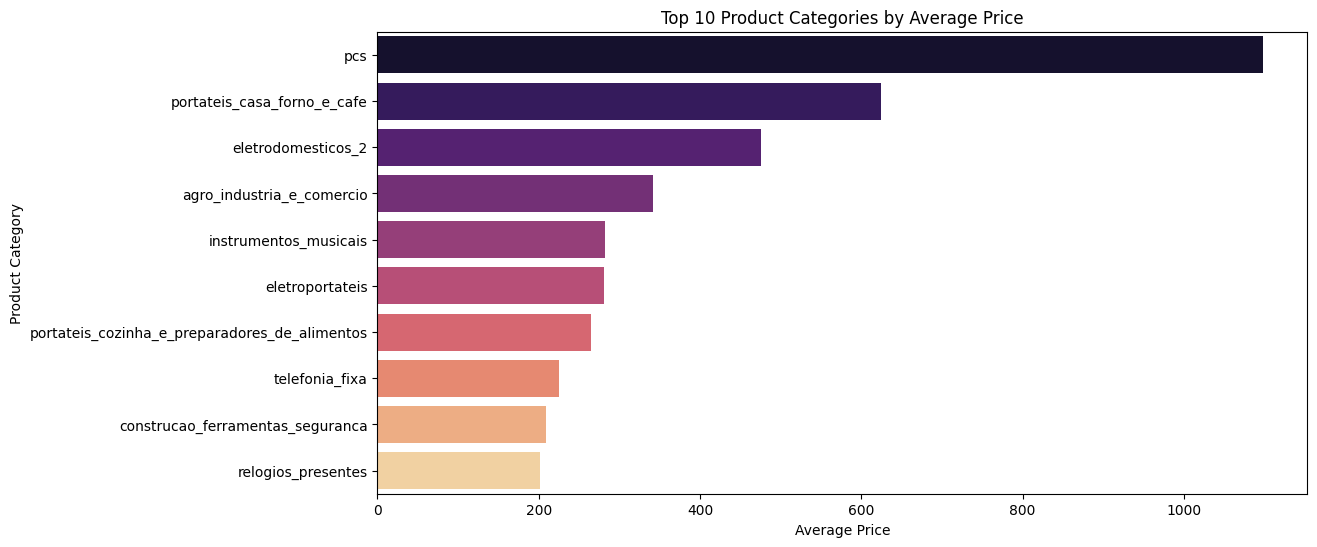

In [9]:
# 2. Rata-rata harga produk berdasarkan kategori
category_price_avg = order_items.groupby('product_category_name')['price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=category_price_avg.values, y=category_price_avg.index, palette="magma")
plt.title("Top 10 Product Categories by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Product Category")
plt.show()

**Insight:**
- Musim Liburan Meningkatkan Penjualan: Penjualan tertinggi terjadi di bulan Desember, kemungkinan karena promo Natal & Tahun Baru.
- Kartu Kredit Mendominasi: Perlu mempertimbangkan program cashback atau cicilan untuk meningkatkan loyalitas pelanggan.

## Analisis Lanjutan (Opsional)

## Conclusion

- Tren jumlah pesanan menunjukkan peningkatan signifikan pada Desember 2017, kemungkinan karena promo akhir tahun.
- Kartu kredit adalah metode pembayaran paling populer, sementara boleto memiliki nilai transaksi lebih rendah, menunjukkan preferensi pelanggan terhadap fleksibilitas pembayaran.